**Name:** Nishtha Lalit Joshi  
**GitHub Username:** joshinishtha99  
**USC ID:** 4515720287

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

%matplotlib inline

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

### (b) Exploring the Data

In [2]:
data = pd.read_excel(
    "../data/CCPP/Folds5x2_pp.xlsx",
    sheet_name=0
)

data.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


#### i. Number of Rows and Columns

In [3]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

print("\nColumnn names:")
print(data.columns.tolist())

print("\nMissing values:")
print(data.isnull().sum())

print("\nData types:")
print(data.dtypes)

Number of rows: 9568
Number of columns: 5

Columnn names:
['AT', 'V', 'AP', 'RH', 'PE']

Missing values:
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

Data types:
AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object


The dataset has 9,568 rows and 5 columns. Each row represents one hourly observation recorded from the power plant.

The columns AT, V, AP, and RH are the predictors, and PE is the response variable that we want to predict.

- AT: Ambient temperature
- V: Exhaust vacuum
- AP: Ambient pressure
- RH: Relative humidity
- PE: Electrical energy output

All five columns contain numerical values, and there are no missing values in the dataset.

#### ii. Pairwise Scatterplots

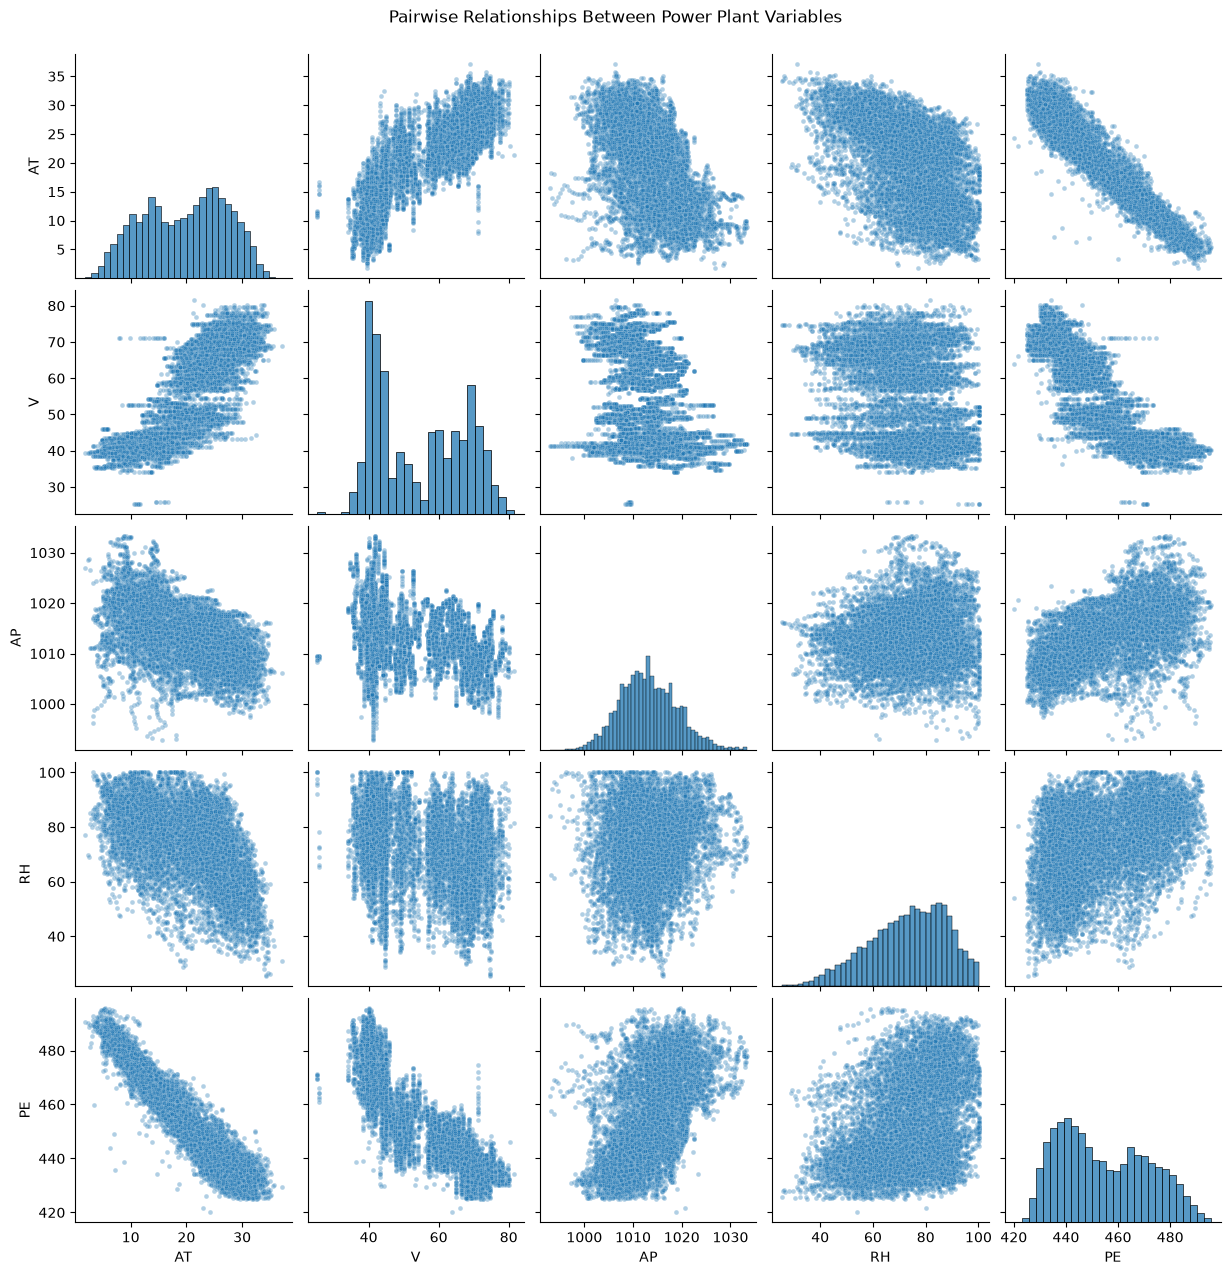

In [4]:
sns.pairplot(
    data,
    diag_kind="hist",
    plot_kws={
        "alpha": 0.35,
        "s": 12
    }
)

plt.suptitle(
    "Pairwise Relationships Between Power Plant Variables",
    y=1.02
)

plt.show()

From the scatterplots, AT has the strongest relationship with PE. As temperature increases, power output generally decreases. V also has a negative relationship with PE.

AP has a positive relationship with PE, but it is not as strong as the relationship between AT and PE. RH also seems to have a weak positive relationship with PE.

AT and V are related to each other, so the predictors are not completely independent. Some of the plots also appear slightly curved, which may mean that nonlinear models could fit the data better. There are also a few points that may be possible outliers.

#### iii. Summary Statistics

In [5]:
summary_table = pd.DataFrame({
    "Mean": data.mean(),
    "Median": data.median(),
    "Minimum": data.min(),
    "Maximum": data.max(),
    "Range": data.max() - data.min(),
    "First Quartile (Q1)": data.quantile(0.25),
    "Third Quartile (Q3)": data.quantile(0.75),
    "Interquartile Range (IQR)": (
        data.quantile(0.75) - data.quantile(0.25)
    )
})

summary_table.round(2)

,Mean,Median,Minimum,Maximum,Range,First Quartile (Q1),Third Quartile (Q3),Interquartile Range (IQR)
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


The summary table shows the mean, median, range, quartiles, and interquartile range for each variable. The mean and median are fairly close for most of the variables. PE ranges from about 420 MW to 496 MW. Compared with the other predictors, AP is concentrated within a relatively narrow range.

### (c) Simple Linear Regression

In [6]:
feature_names = ["AT", "V", "AP", "RH"]

fitted_simple_models = {}
regression_rows = []

for feature in feature_names:
    feature_with_intercept = sm.add_constant(data[[feature]])
    power_output = data["PE"]

    fitted_model = sm.OLS(
        power_output,
        feature_with_intercept
    ).fit()

    fitted_simple_models[feature] = fitted_model

    regression_rows.append({
        "Feature": feature,
        "Intercept": fitted_model.params["const"],
        "Slope": fitted_model.params[feature],
        "P-value": fitted_model.pvalues[feature],
        "R-squared": fitted_model.rsquared
    })

simple_regression_summary = pd.DataFrame(regression_rows)
simple_regression_summary.round(4)

,Feature,Intercept,Slope,P-value,R-squared
0,AT,497.0341,-2.1713,0.0,0.8989
1,V,517.8015,-1.1681,0.0,0.7565
2,AP,-1055.2610,1.4899,0.0,0.2688
3,RH,420.9618,0.4557,0.0,0.1519


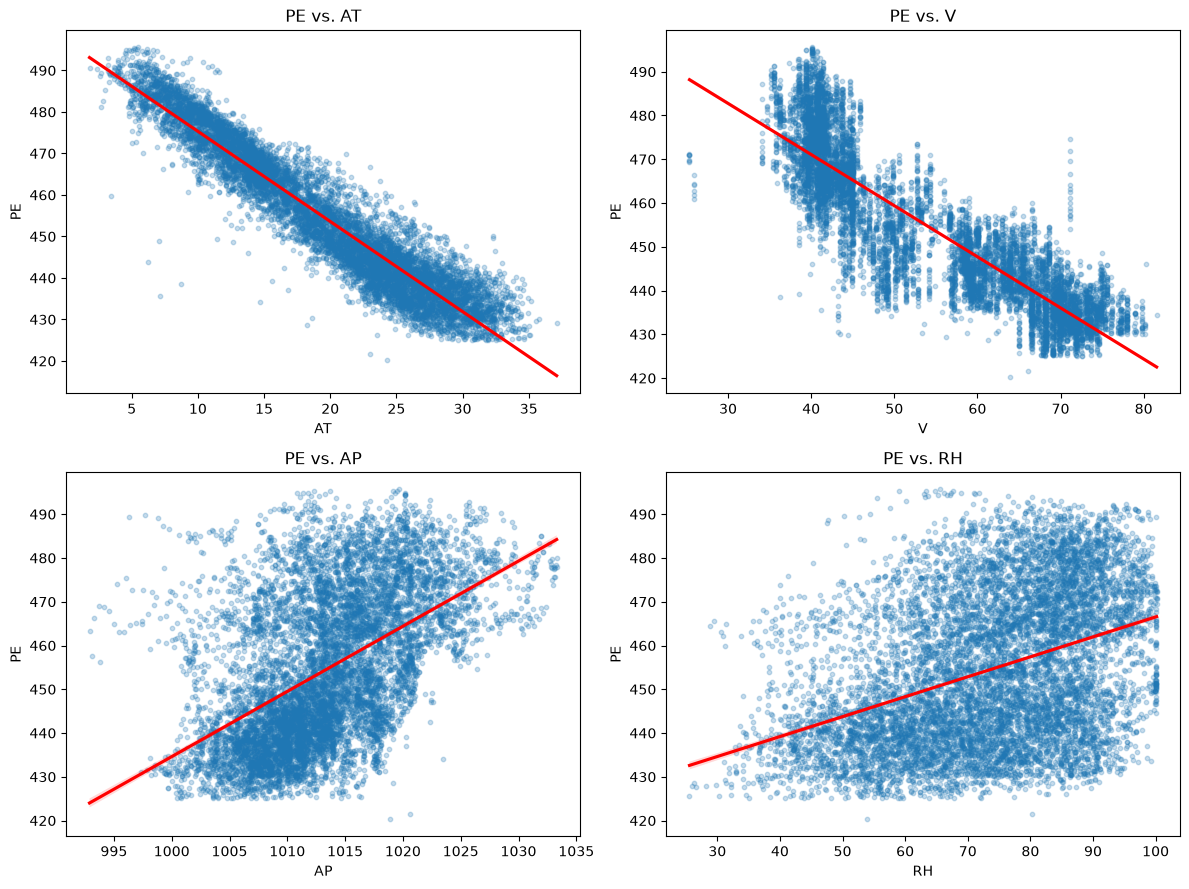

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for feature, ax in zip(feature_names, axes.flatten()):
    sns.regplot(
        data=data,
        x=feature,
        y="PE",
        ax=ax,
        scatter_kws={
            "alpha": 0.25,
            "s": 10
        },
        line_kws={
            "color": "red"
        }
    )

    ax.set_title(f"PE vs. {feature}")

plt.tight_layout()
plt.show()

In [8]:
outlier_results = []

for feature, fitted_model in fitted_simple_models.items():
    influence = fitted_model.get_influence()
    studentized_residuals = influence.resid_studentized_external

    outlier_count = np.sum(
        np.abs(studentized_residuals) > 3
    )

    outlier_results.append({
        "Feature": feature,
        "Possible Outliers": outlier_count
    })

pd.DataFrame(outlier_results)

,Feature,Possible Outliers
0,AT,42
1,V,33
2,AP,30
3,RH,2


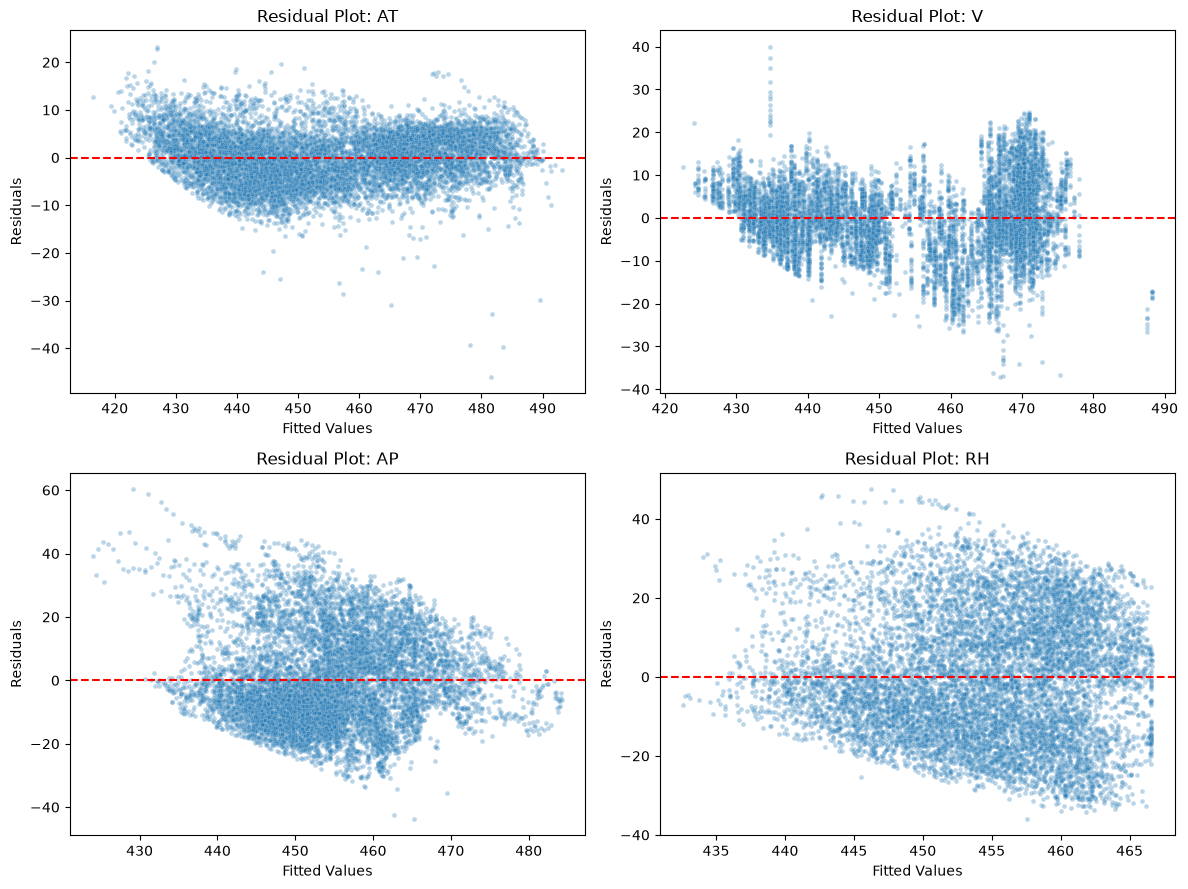

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for feature, ax in zip(feature_names, axes.flatten()):
    fitted_model = fitted_simple_models[feature]

    sns.scatterplot(
        x=fitted_model.fittedvalues,
        y=fitted_model.resid,
        ax=ax,
        alpha=0.3,
        s=12
    )

    ax.axhline(
        0,
        color="red",
        linestyle="--"
    )

    ax.set_title(f"Residual Plot: {feature}")
    ax.set_xlabel("Fitted Values")
    ax.set_ylabel("Residuals")

plt.tight_layout()
plt.show()

In [10]:
simple_regression_summary.round(6)

,Feature,Intercept,Slope,P-value,R-squared
0,AT,497.034120,-2.171320,0.0,0.898948
1,V,517.801526,-1.168135,0.0,0.756518
2,AP,-1055.260989,1.489872,0.0,0.268769
3,RH,420.961766,0.455650,0.0,0.151939


I fitted a separate simple linear regression model for each predictor.

AT has a coefficient of -2.1713, meaning that a one-degree increase in temperature is associated with an average decrease of about 2.17 MW in power output. Its R-squared value is 0.8989, so AT alone explains about 89.9% of the variation in PE.

V also has a negative relationship with PE. Its coefficient is -1.1681 and its R-squared value is 0.7565.

AP and RH both have positive coefficients. However, their R-squared values are only 0.2688 and 0.1519, so they do not explain PE as well individually.

The p-values for all four predictors are extremely small, so all four predictors have a statistically significant association with PE.

Using an absolute studentized residual greater than 3, I found 42 possible outliers for AT, 33 for V, 30 for AP, and 2 for RH. I would not remove them automatically because they may still be valid observations. The residual plots also show noticeable patterns, suggesting that some relationships may not be completely linear.

### (d) Multiple Linear Regression

In [11]:
input_features = data[["AT", "V", "AP", "RH"]]
input_features = sm.add_constant(input_features)

power_output = data["PE"]

combined_regression = sm.OLS(
    power_output,
    input_features
).fit()

print(combined_regression.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:12:16   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

In [12]:
combined_results = pd.DataFrame({
    "Coefficient": combined_regression.params,
    "P-value": combined_regression.pvalues
})

combined_results.round(6)

,Coefficient,P-value
const,454.609274,0.0
AT,-1.977513,0.0
V,-0.233916,0.0
AP,0.062083,0.0
RH,-0.158054,0.0


In [13]:
print("R-squared:", combined_regression.rsquared)
print(
    "Adjusted R-squared:",
    combined_regression.rsquared_adj
)

R-squared: 0.9286960898122537
Adjusted R-squared: 0.9286662648994909


I fitted a multiple linear regression model using AT, V, AP, and RH together. The model has an R-squared value of 0.9287, which means that it explains about 92.9% of the variation in PE.

The estimated regression equation is:

PE = 454.6093 - 1.9775(AT) - 0.2339(V) + 0.0621(AP) - 0.1581(RH)

The p-values for AT, V, AP, and RH are all less than 0.05. Therefore, I reject the null hypothesis for all four predictors. Each predictor has a statistically significant relationship with PE after controlling for the other predictors.

### (e) Comparison of Simple and Multiple Regression Coefficients

In [14]:
individual_slopes = [
    fitted_simple_models[feature].params[feature]
    for feature in feature_names
]

combined_slopes = [
    combined_regression.params[feature]
    for feature in feature_names
]

slope_comparison = pd.DataFrame({
    "Feature": feature_names,
    "Individual Model": individual_slopes,
    "Combined Model": combined_slopes
})

slope_comparison.round(4)

,Feature,Individual Model,Combined Model
0,AT,-2.1713,-1.9775
1,V,-1.1681,-0.2339
2,AP,1.4899,0.0621
3,RH,0.4557,-0.1581


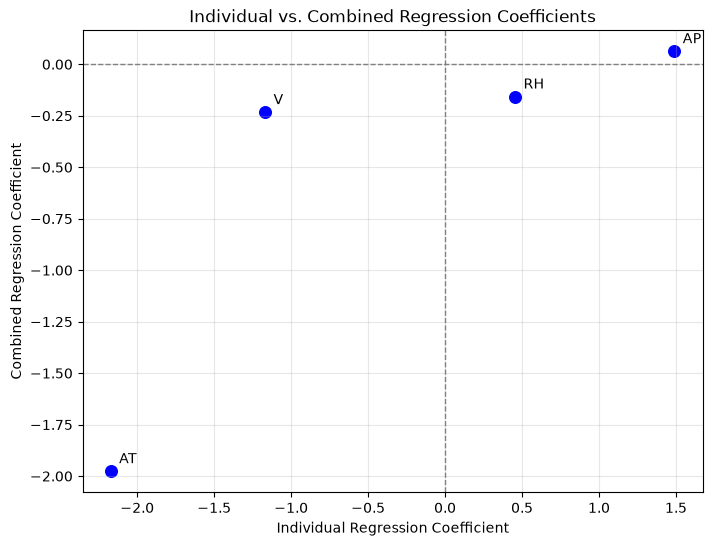

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    individual_slopes,
    combined_slopes,
    color="blue",
    s=70
)

for feature, x, y in zip(
    feature_names,
    individual_slopes,
    combined_slopes
):
    plt.annotate(
        feature,
        (x, y),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Individual Regression Coefficient")
plt.ylabel("Combined Regression Coefficient")
plt.title("Individual vs. Combined Regression Coefficients")
plt.grid(alpha=0.3)

plt.show()

The coefficients from the simple and multiple regression models are noticeably different.

AT remains strongly negative in both models, although its coefficient changes from -2.1713 to -1.9775. The coefficient for V changes from -1.1681 to -0.2339, while the coefficient for AP changes from 1.4899 to 0.0621.

The largest change is for RH. Its coefficient is positive in the simple regression model but negative in the multiple regression model. This happens because the simple model does not account for the relationships between RH and the other predictors. Once AT, V, and AP are included, the estimated effect of RH changes.

### (f) Nonlinear Associations

In [16]:
cubic_models = {}
nonlinear_results = []

for feature in feature_names:
    cubic_formula = (
        f"PE ~ {feature} "
        f"+ I({feature} ** 2) "
        f"+ I({feature} ** 3)"
    )

    cubic_fit = smf.ols(
        formula=cubic_formula,
        data=data
    ).fit()

    cubic_models[feature] = cubic_fit

    nonlinear_results.append({
        "Feature": feature,
        "Linear p-value": cubic_fit.pvalues[feature],
        "Quadratic p-value": cubic_fit.pvalues[
            f"I({feature} ** 2)"
        ],
        "Cubic p-value": cubic_fit.pvalues[
            f"I({feature} ** 3)"
        ],
        "R-squared": cubic_fit.rsquared
    })

nonlinear_summary = pd.DataFrame(nonlinear_results)
nonlinear_summary

,Feature,Linear p-value,Quadratic p-value,Cubic p-value,R-squared
0,AT,7.898147e-07,8.833045e-73,3.652185e-110,0.911883
1,V,2.526589e-05,7.684969e-01,1.373489e-02,0.775022
2,AP,4.502735e-17,3.666705e-17,8.264146e-18,0.274863
3,RH,3.772510e-04,9.395430e-06,1.440279e-05,0.153743


In [17]:
nonlinear_summary.style.format({
    "Linear p-value": "{:.4e}",
    "Quadratic p-value": "{:.4e}",
    "Cubic p-value": "{:.4e}",
    "R-squared": "{:.4f}"
})

,Feature,Linear p-value,Quadratic p-value,Cubic p-value,R-squared
0,AT,7.8981e-07,8.8330e-73,3.6522e-110,0.9119
1,V,2.5266e-05,7.6850e-01,1.3735e-02,0.7750
2,AP,4.5027e-17,3.6667e-17,8.2641e-18,0.2749
3,RH,3.7725e-04,9.3954e-06,1.4403e-05,0.1537


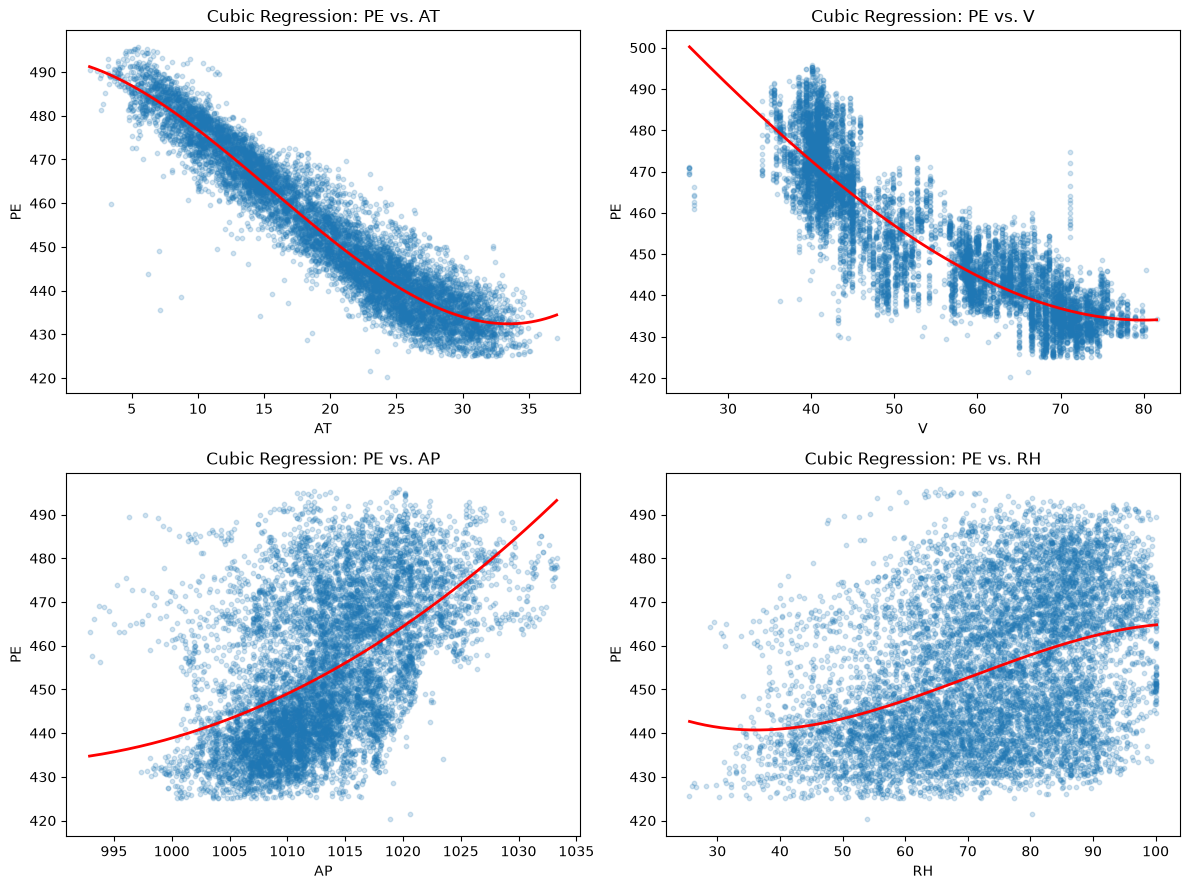

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for feature, ax in zip(feature_names, axes.flatten()):
    cubic_model = cubic_models[feature]

    feature_values = np.linspace(
        data[feature].min(),
        data[feature].max(),
        300
    )

    prediction_data = pd.DataFrame({
        feature: feature_values
    })

    predicted_power = cubic_model.predict(prediction_data)

    ax.scatter(
        data[feature],
        data["PE"],
        alpha=0.2,
        s=10
    )

    ax.plot(
        feature_values,
        predicted_power,
        color="red",
        linewidth=2
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("PE")
    ax.set_title(f"Cubic Regression: PE vs. {feature}")

plt.tight_layout()
plt.show()

In [19]:
nonlinear_summary

,Feature,Linear p-value,Quadratic p-value,Cubic p-value,R-squared
0,AT,7.898147e-07,8.833045e-73,3.652185e-110,0.911883
1,V,2.526589e-05,7.684969e-01,1.373489e-02,0.775022
2,AP,4.502735e-17,3.666705e-17,8.264146e-18,0.274863
3,RH,3.772510e-04,9.395430e-06,1.440279e-05,0.153743


In [20]:
for feature, cubic_model in cubic_models.items():
    print(f"\n{feature}")
    print(cubic_model.pvalues)


AT
Intercept      0.000000e+00
AT             7.898147e-07
I(AT ** 2)     8.833045e-73
I(AT ** 3)    3.652185e-110
dtype: float64

V
Intercept    0.000000
V            0.000025
I(V ** 2)    0.768497
I(V ** 3)    0.013735
dtype: float64

AP
Intercept     4.502734e-17
AP            4.502735e-17
I(AP ** 2)    3.666705e-17
I(AP ** 3)    8.264146e-18
dtype: float64

RH
Intercept     0.000000
RH            0.000377
I(RH ** 2)    0.000009
I(RH ** 3)    0.000014
dtype: float64


I fitted a cubic regression model for each predictor using linear, quadratic, and cubic terms.

For AT, both the quadratic and cubic terms have extremely small p-values, so there is strong evidence of a nonlinear relationship with PE.

For V, the quadratic term is not significant because its p-value is 0.7685. However, the cubic term has a p-value of 0.0137, so there is still evidence of nonlinearity.

For AP, both the quadratic and cubic terms are statistically significant.

For RH, both the quadratic and cubic terms are also statistically significant.

Therefore, there is evidence of a nonlinear association between each of the four predictors and PE. The fitted curves also show that these relationships are not perfectly straight.

### (g) Interaction Effects

In [21]:
pairwise_model = smf.ols(
    formula="PE ~ (AT + V + AP + RH) ** 2",
    data=data
).fit()

print(pairwise_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:12:16   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [22]:
pairwise_terms = [
    term
    for term in pairwise_model.params.index
    if ":" in term
]

pairwise_results = pd.DataFrame({
    "Coefficient": pairwise_model.params[pairwise_terms],
    "P-value": pairwise_model.pvalues[pairwise_terms]
})

pairwise_results

,Coefficient,P-value
AT:V,0.020971,3.333358e-117
AT:AP,0.001759,4.520509e-01
AT:RH,-0.005230,1.216944e-10
V:AP,0.006812,2.877026e-07
V:RH,0.000839,8.619366e-02
AP:RH,-0.001612,3.360557e-02


In [23]:
significant_pairwise_terms = pairwise_results[
    pairwise_results["P-value"] < 0.05
]

significant_pairwise_terms

,Coefficient,P-value
AT:V,0.020971,3.333358e-117
AT:RH,-0.005230,1.216944e-10
V:AP,0.006812,2.877026e-07
AP:RH,-0.001612,3.360557e-02


I fitted a linear regression model containing all four predictors and all six pairwise interaction terms.

Four interaction terms are statistically significant at the 0.05 level: AT:V, AT:RH, V:AP, and AP:RH. The AT:AP and V:RH interactions are not significant because their p-values are greater than 0.05.

Therefore, there is evidence that some predictors interact with each other when predicting PE. In other words, the relationship between one predictor and PE can depend on the value of another predictor.

### (h) Improving the Regression Model

In [24]:
train_data, test_data = train_test_split(
    data,
    test_size=0.30,
    random_state=42
)

print("Training observations:", train_data.shape[0])
print("Testing observations:", test_data.shape[0])

Training observations: 6697
Testing observations: 2871


In [25]:
linear_train_model = smf.ols(
    formula="PE ~ AT + V + AP + RH",
    data=train_data
).fit()

linear_train_predictions = linear_train_model.predict(train_data)
linear_test_predictions = linear_train_model.predict(test_data)

linear_train_mse = mean_squared_error(
    train_data["PE"],
    linear_train_predictions
)

linear_test_mse = mean_squared_error(
    test_data["PE"],
    linear_test_predictions
)

print("Linear model train MSE:", linear_train_mse)
print("Linear model test MSE:", linear_test_mse)

Linear model train MSE: 20.580839725738695
Linear model test MSE: 21.239856938225444


In [26]:
full_formula = """
PE ~ AT + V + AP + RH
+ I(AT ** 2) + I(V ** 2) + I(AP ** 2) + I(RH ** 2)
+ AT:V + AT:AP + AT:RH
+ V:AP + V:RH + AP:RH
"""

full_model = smf.ols(
    formula=full_formula,
    data=train_data
).fit()

full_model_results = pd.DataFrame({
    "Coefficient": full_model.params,
    "P-value": full_model.pvalues
})

full_model_results

,Coefficient,P-value
Intercept,-7664.980854,8.518151e-08
AT,-7.288543,4.460633e-02
V,-1.958957,2.671816e-01
AP,15.930817,9.534685e-09
RH,3.912130,1.429286e-04
I(AT ** 2),0.018495,5.017196e-07
I(V ** 2),-0.000365,6.998020e-01
I(AP ** 2),-0.007758,8.522142e-09
I(RH ** 2),-0.001895,1.395087e-09
AT:V,0.009465,3.195237e-03


In [27]:
selected_formula = """
PE ~ AT + V + AP + RH
+ I(AT ** 2) + I(AP ** 2) + I(RH ** 2)
+ AT:V + AT:RH + AP:RH
"""

selected_regression = smf.ols(
    formula=selected_formula,
    data=train_data
).fit()

selected_model_summary = pd.DataFrame({
    "Estimate": selected_regression.params,
    "P-value": selected_regression.pvalues
})

selected_model_summary

,Estimate,P-value
Intercept,-10457.507603,1.325324e-21
AT,-2.429290,2.671314e-124
V,-0.454214,4.960489e-45
AP,21.153085,1.534727e-22
RH,5.675420,6.572307e-14
I(AT ** 2),0.016994,8.530847e-14
I(AP ** 2),-0.010195,1.653455e-21
I(RH ** 2),-0.002078,2.519751e-14
AT:V,0.008017,3.753670e-08
AT:RH,-0.006881,2.412307e-15


In [28]:
train_predictions_selected = selected_regression.predict(train_data)
test_predictions_selected = selected_regression.predict(test_data)

train_mse_selected = mean_squared_error(
    train_data["PE"],
    train_predictions_selected
)

test_mse_selected = mean_squared_error(
    test_data["PE"],
    test_predictions_selected
)

In [29]:
model_error_comparison = pd.DataFrame({
    "Model": [
        "Basic Linear Model",
        "Selected Nonlinear Model"
    ],
    "Training MSE": [
        linear_train_mse,
        train_mse_selected
    ],
    "Testing MSE": [
        linear_test_mse,
        test_mse_selected
    ]
})

model_error_comparison

,Model,Training MSE,Testing MSE
0,Basic Linear Model,20.580840,21.239857
1,Selected Nonlinear Model,17.917813,18.694346


I randomly divided the dataset into 70% training data and 30% testing data using a random state of 42.

The multiple linear regression model had a training MSE of 20.5808 and a test MSE of 21.2399.

I then fitted a model containing all pairwise interactions and quadratic terms. Based on the p-values from the training data, I removed V², AT:AP, V:AP, and V:RH because they were not significant. I kept all four main effects because they were either significant or needed to support an interaction or quadratic term in the model.

After removing the insignificant terms, the reduced model had a training MSE of 17.9178 and a test MSE of 18.6943. Since both values are lower than those of the basic linear model, including selected nonlinear and interaction terms improved the model.

### (i) KNN Regression

In [30]:
features = ["AT", "V", "AP", "RH"]

X_train = train_data[features]
y_train = train_data["PE"]

X_test = test_data[features]
y_test = test_data["PE"]

In [31]:
neighbor_counts = range(1, 101)

raw_training_errors = []
raw_testing_errors = []

for neighbor_count in neighbor_counts:
    raw_knn_model = KNeighborsRegressor(
        n_neighbors=neighbor_count
    )

    raw_knn_model.fit(X_train, y_train)

    training_estimates = raw_knn_model.predict(X_train)
    testing_estimates = raw_knn_model.predict(X_test)

    raw_training_errors.append(
        mean_squared_error(
            y_train,
            training_estimates
        )
    )

    raw_testing_errors.append(
        mean_squared_error(
            y_test,
            testing_estimates
        )
    )

In [32]:
scaler = StandardScaler()

X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

In [33]:
normalized_training_errors = []
normalized_testing_errors = []

for neighbor_count in neighbor_counts:
    normalized_knn_model = KNeighborsRegressor(
        n_neighbors=neighbor_count
    )

    normalized_knn_model.fit(
        X_train_normalized,
        y_train
    )

    normalized_training_predictions = normalized_knn_model.predict(
        X_train_normalized
    )

    normalized_testing_predictions = normalized_knn_model.predict(
        X_test_normalized
    )

    normalized_training_errors.append(
        mean_squared_error(
            y_train,
            normalized_training_predictions
        )
    )

    normalized_testing_errors.append(
        mean_squared_error(
            y_test,
            normalized_testing_predictions
        )
    )

In [34]:
best_raw_index = np.argmin(raw_testing_errors)
best_normalized_index = np.argmin(normalized_testing_errors)

best_raw_k = list(neighbor_counts)[best_raw_index]
best_normalized_k = list(neighbor_counts)[best_normalized_index]

print("Best k for raw features:", best_raw_k)
print("Best raw test MSE:", raw_testing_errors[best_raw_index])

print("\nBest k for normalized features:", best_normalized_k)
print(
    "Best normalized test MSE:",
    normalized_testing_errors[best_normalized_index]
)

Best k for raw features: 5
Best raw test MSE: 15.726819842563568

Best k for normalized features: 4
Best normalized test MSE: 14.305669422675024


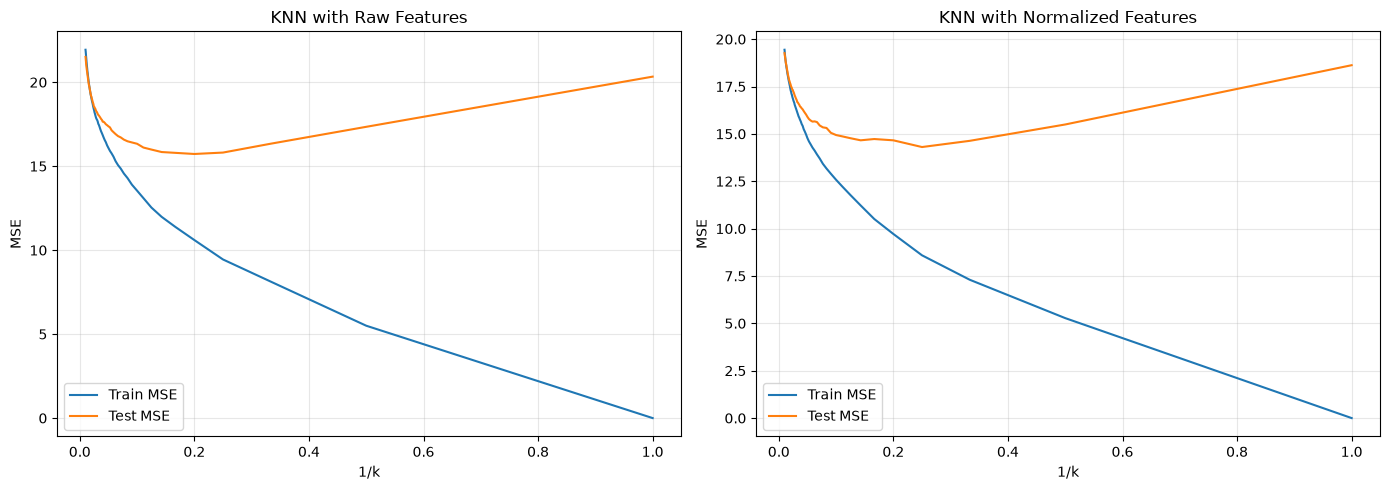

In [35]:
inverse_neighbor_counts = [
    1 / neighbor_count
    for neighbor_count in neighbor_counts
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    inverse_neighbor_counts,
    raw_training_errors,
    label="Train MSE"
)

axes[0].plot(
    inverse_neighbor_counts,
    raw_testing_errors,
    label="Test MSE"
)

axes[0].set_title("KNN with Raw Features")
axes[0].set_xlabel("1/k")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    inverse_neighbor_counts,
    normalized_training_errors,
    label="Train MSE"
)

axes[1].plot(
    inverse_neighbor_counts,
    normalized_testing_errors,
    label="Test MSE"
)

axes[1].set_title("KNN with Normalized Features")
axes[1].set_xlabel("1/k")
axes[1].set_ylabel("MSE")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

I performed KNN regression for values of k from 1 to 100 using both raw and normalized predictors.

For the raw features, the best value was k = 5, with a test MSE of 15.7268.

For the normalized features, the best value was k = 4, with a test MSE of 14.3057. Therefore, KNN performed better after normalization.

At k = 1, the training MSE is zero because every training observation is its own nearest neighbor. However, the test error is higher, which shows that the model is overfitting. As k increases, the test error first decreases and then increases again.

### (j) Comparison of KNN and Linear Regression

The reduced regression model containing selected nonlinear and interaction terms had a test MSE of 18.6943.

The best KNN model using raw features had a test MSE of 15.7268, while the best normalized KNN model had a test MSE of 14.3057.

Therefore, both KNN models performed better than the regression model on the test data. The normalized KNN model performed the best overall. Normalization improved KNN because its predictions are based on distances, and the predictors have different numerical scales. Without normalization, variables with larger scales can have too much influence on the distance calculation.

KNN can capture local and nonlinear patterns without specifying their exact form, which likely explains its lower test error. However, the regression model is easier to interpret because it provides coefficients and p-values for individual predictors and interactions.

## 2. ISLR 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.
sol : A flexible method would probably perform better. We have a large number of observations and only a few predictors, so the model has enough data to learn a more complicated pattern without overfitting too much.

### (b) The number of predictors p is extremely large, and the number of observations n is small.
sol : An inflexible method would probably perform better. With many predictors and very few observations, a flexible method is likely to fit random patterns in the training data instead of the actual relationship.

### (c) The relationship between the predictors and response is highly non-linear.
soL : A flexible method would perform better because the relationship is highly nonlinear. An inflexible method may be too simple to capture the shape of the relationship.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.
sol : An inflexible method would probably perform better. A high error variance means that the data contains a lot of noise. A flexible method may try to fit that noise, which would hurt its performance on new data.

## 3. ISLR 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.
sol : Using Euclidean distance: The distances we got are :

- Observation 1: $3$
- Observation 2: $2$
- Observation 3: $\sqrt{10} \approx 3.16$
- Observation 4: $\sqrt{5} \approx 2.24$
- Observation 5: $\sqrt{2} \approx 1.41$
- Observation 6: $\sqrt{3} \approx 1.73$

### (b) What is our prediction with K = 1? Why? 
sol : For k=1, the prediction is Green. Observation 5 is the closest observation to the test point, and its response is Green.

### (c) What is our prediction with K = 3? Why?
sol : For k=3, the three closest observations are:
1. Observation 5: Green
2. Observation 6: Red
3. Observation 2: Red
Since two of the three observations are Red, the prediction is Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?
sol : We would expect the best value of K to be small. A smaller K produces a more flexible decision boundary, which is better able to follow a highly nonlinear pattern. A large K averages over more observations and creates a smoother, less flexible boundary.